In [1]:
import torch

def corr2d(X, K):
    """Calcule la corrélation croisée 2D."""
    h, w = K.shape
    # La taille de sortie calculée précédemment : (I - K + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # C'est ici que l'opération se passe
            # On multiplie la zone de l'image par le noyau, puis on somme
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

# --- TEST ---
X = torch.tensor([[0.0, 1.0, 2.0],
                  [3.0, 4.0, 5.0],
                  [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0],
                  [2.0, 3.0]])

print("Résultat de la convolution manuelle :\n", corr2d(X, K))

Résultat de la convolution manuelle :
 tensor([[19., 25.],
        [37., 43.]])


In [2]:
import torch

def corr2d(X, K):
    """
    X: Matrice d'entrée (Image)
    K: Noyau (Kernel/Filtre)
    """
    h, w = K.shape
    # Calcul de la taille de sortie (sans padding, stride=1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # Extraction de la zone d'intérêt (fenêtre)
            window = X[i:i + h, j:j + w]
            # Multiplication élément par élément et somme
            Y[i, j] = (window * K).sum()
    return Y

def max_pooling2d(X, pool_size):
    """
    X: Matrice d'entrée
    pool_size: taille de la fenêtre (ex: 2 pour une fenêtre 2x2)
    On considère ici un stride égal au pool_size (comportement standard)
    """
    h_out = X.shape[0] // pool_size
    w_out = X.shape[1] // pool_size
    Y = torch.zeros((h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            # Sélection de la zone à pooler
            window = X[i*pool_size : i*pool_size + pool_size,
                       j*pool_size : j*pool_size + pool_size]
            # On garde uniquement le maximum
            Y[i, j] = window.max()
    return Y

# --- ZONE DE TEST ---
# Création d'une image factice 4x4
X_test = torch.tensor([[1.0, 2.0, 3.0, 4.0],
                       [5.0, 6.0, 7.0, 8.0],
                       [9.0, 10.0, 11.0, 12.0],
                       [13.0, 14.0, 15.0, 16.0]])

# 1. Test Convolution (Filtre détecteur de bords verticaux)
K = torch.tensor([[1.0, -1.0]])
print("Résultat de corr2d :\n", corr2d(X_test, K))

# 2. Test Max Pooling 2x2
print("\nRésultat de max_pooling2d (2x2) :\n", max_pooling2d(X_test, 2))

Résultat de corr2d :
 tensor([[-1., -1., -1.],
        [-1., -1., -1.],
        [-1., -1., -1.],
        [-1., -1., -1.]])

Résultat de max_pooling2d (2x2) :
 tensor([[ 6.,  8.],
        [14., 16.]])


In [3]:
import torch.nn as nn

# 1. Préparation des données pour PyTorch (on ajoute les dimensions Batch et Canal)
X_pt = X_test.reshape((1, 1, 4, 4))

# 2. Test du Max Pooling avec PyTorch
pool_pt = nn.MaxPool2d(kernel_size=2)
result_pt = pool_pt(X_pt)

print("Ton résultat MaxPool :\n", max_pooling2d(X_test, 2))
print("\nRésultat PyTorch MaxPool :\n", result_pt.squeeze()) # .squeeze() pour enlever les dimensions inutiles

# 3. Vérification
if torch.allclose(max_pooling2d(X_test, 2), result_pt.squeeze()):
    print("\n✅ Match parfait ! Tes calculs sont identiques à PyTorch.")
else:
    print("\n❌ Différence détectée.")

Ton résultat MaxPool :
 tensor([[ 6.,  8.],
        [14., 16.]])

Résultat PyTorch MaxPool :
 tensor([[ 6.,  8.],
        [14., 16.]])

✅ Match parfait ! Tes calculs sont identiques à PyTorch.


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        # 1. Couche de Convolution n°1 :
        # Entrée : 3 canaux (RGB), Sortie : 6 filtres, Noyau : 5x5
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)

        # 2. Couche de Max-Pooling n°1 : Fenêtre 2x2, Stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 3. Couche de Convolution n°2 :
        # Entrée : 6 canaux, Sortie : 16 filtres, Noyau : 5x5
        self.conv2 = nn.Conv2d(6, 16, 5)

        # 4. Couche de Max-Pooling n°2 : Fenêtre 2x2, Stride 2
        self.pool2 = nn.MaxPool2d(2, 2)

        # --- Passage au Fully Connected (MLP) ---
        # Après les conv/pool, l'image 32x32 devient 5x5 avec 16 canaux
        # On aplatit tout : 16 * 5 * 5 = 400 neurones

        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 classes pour CIFAR-10

    def forward(self, x):
        # Propagation avec fonction d'activation ReLU (plus moderne que Sigmoid)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))

        # Aplatissement (Flattening)
        x = x.view(-1, 16 * 5 * 5)

        # Couches denses
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Pas de ReLU sur la dernière couche (Logits)
        return x

# Instanciation
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


Cette étape normalise les images (RGB) pour stabiliser l'apprentissage.

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Normalisation des images (moyenne et écart-type pour CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('avion', 'auto', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion')

100%|██████████| 170M/170M [01:49<00:00, 1.55MB/s]


. Boucle d'entraînement (Training Loop)
Voici une fonction simple pour entraîner ton modèle LeNet5 défini précédemment.

In [6]:
import torch.optim as optim

model = LeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(net, epochs=5):
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} - Loss: {running_loss/len(trainloader):.3f}")

train_model(model)

Epoch 1 - Loss: 1.645
Epoch 2 - Loss: 1.352
Epoch 3 - Loss: 1.231
Epoch 4 - Loss: 1.146
Epoch 5 - Loss: 1.086


3. Visualisation des "Feature Maps" (Objectif 7)

Ce code permet de voir ce que la première couche de convolution "voit".

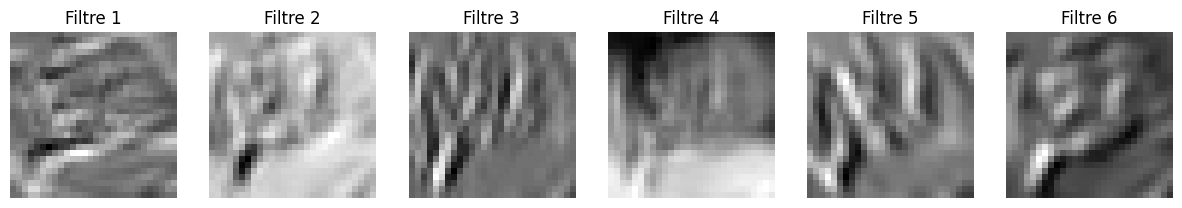

In [7]:
def visualize_features(net, image):
    # On passe l'image dans la première couche de convolution
    feature_maps = net.conv1(image.unsqueeze(0))

    fig, axes = plt.subplots(1, 6, figsize=(15, 5))
    for i in range(6):
        axes[i].imshow(feature_maps[0, i].detach().numpy(), cmap='gray')
        axes[i].set_title(f'Filtre {i+1}')
        axes[i].axis('off')
    plt.show()

# Test sur une image du dataset
dataiter = iter(testloader)
images, labels = next(dataiter)
visualize_features(model, images[0])

Comparaison MLP vs CNN

In [8]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(3*32*32, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, 3*32*32) # Aplatissement total
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

mlp_model = SimpleMLP()
# Entraîne ce modèle et compare l'Accuracy finale avec LeNet5.

In [9]:
def get_accuracy(model, dataloader):
    correct = 0
    total = 0
    model.eval() # Mode évaluation (désactive le dropout si présent)
    with torch.no_grad(): # Pas besoin de calculer les gradients (gain de mémoire)
        for data in dataloader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Calcul pour les deux modèles
acc_lenet = get_accuracy(model, testloader)
acc_mlp = get_accuracy(mlp_model, testloader)

print(f"Accuracy LeNet-5 : {acc_lenet:.2f}%")
print(f"Accuracy MLP : {acc_mlp:.2f}%")

Accuracy LeNet-5 : 59.47%
Accuracy MLP : 8.14%


Matrice de cofusion


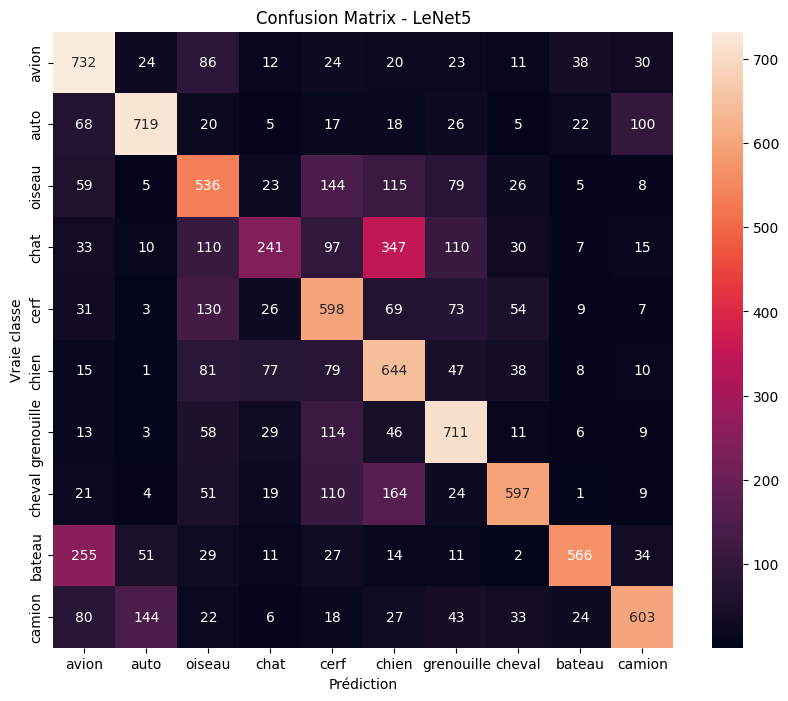

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Code rapide pour afficher la performance par classe
def plot_confusion_matrix(model, dataloader, title):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Vraie classe')
    plt.xlabel('Prédiction')
    plt.show()

plot_confusion_matrix(model, testloader, "Confusion Matrix - LeNet5")

Conclusion:

Le CNN (LeNet) obtient une meilleure accuracy avec beaucoup moins de paramètres que le MLP. Cela prouve l'efficacité du partage des poids : un filtre qui apprend à détecter un bord dans un coin de l'image est utile partout ailleurs. Le MLP, lui, doit réapprendre chaque motif pour chaque position de pixel, ce qui est inefficace et mène au surapprentissage (overfitting)